# OCR + text-RAG on a real Hebrew document

**Meeting 13 — AI Engineering Course (BGU)**

This notebook walks the **OCR-first** RAG strategy end-to-end on a real
photograph of a Hebrew document — an Israeli annual property-tax bill
(*חשבון שנתי של מיסים / ארנונה*) from the Lachish Regional Council.
The image is tilted, photographed on a desk, and entirely in Hebrew with
mixed numbers and a multi-column table. It is exactly the kind of input
production RAG pipelines have to handle.

We will:

1. Load the scanned page as it came off the phone camera.
2. Apply basic image preprocessing (grayscale, contrast, deskew check).
3. Try **EasyOCR** in English-only mode — it has no Hebrew model, and the
   failure is the point. Same lesson for Tesseract without the `heb` pack.
4. Use **Claude multimodal as the OCR engine** (with a deterministic
   pre-transcribed fallback when no `ANTHROPIC_API_KEY` is set). Real
   production teams increasingly do exactly this — and it's our cleanest
   path to high-quality Hebrew text without installing tesseract / paddleocr.
5. Normalize, chunk, and embed with a **multilingual** sentence-transformer.
6. Build a tiny vector index and answer Hebrew + English questions about
   the bill.
7. End with queries this pipeline **can't** answer — the bridge to
   Meeting 14 and visual retrieval.

## 0 — Setup

The `llm` conda env on the course machine has everything needed
(`Pillow`, `easyocr`, `sentence-transformers`, `python-bidi`, `anthropic`).
If you're on a fresh environment:

```bash
pip install easyocr sentence-transformers python-bidi anthropic Pillow numpy
```

The scanned page lives at `artifacts_m13/IMG_20260525_123259.jpg` — swap
this path to point at any other Hebrew document you want to try.

In [2]:
import os, io, re, json, base64, textwrap, unicodedata
from pathlib import Path

import numpy as np
from PIL import Image

ARTIFACTS = Path("artifacts_m13"); ARTIFACTS.mkdir(exist_ok=True)
# SCAN_PATH = ARTIFACTS / "IMG_20260525_123259.jpg"
SCAN_PATH = ARTIFACTS / "IMG_20260525_170752.jpg"

assert SCAN_PATH.exists(), f"Drop the scan at {SCAN_PATH} before running."
print("artifacts dir:", ARTIFACTS.resolve())
print("scan size on disk:", SCAN_PATH.stat().st_size, "bytes")

artifacts dir: /media/amir/Windows-SSD/Users/User/Documents/bgu-ai/bgu-presentations/artifacts_m13
scan size on disk: 675682 bytes


## 1 — Load the scanned page

This is a real photograph of an Israeli annual property-tax bill
(*חשבון שנתי של מיסים*) from the Lachish Regional Council. Things to notice
before we touch any OCR:

- The page is **tilted** (~3–5°) — typical of phone photos.
- The background is **non-white** — desk wood is visible at the edges.
- The header and table use a mix of **red and black** ink — the OCR engine
  must be robust to colour.
- The text is **entirely Hebrew**, with numbers and dates as LTR runs inside.
- There is a **multi-column table** in the middle of the page.

We display the image first, then size it down so it fits in the notebook view.

scan resolution: (3472, 2516)


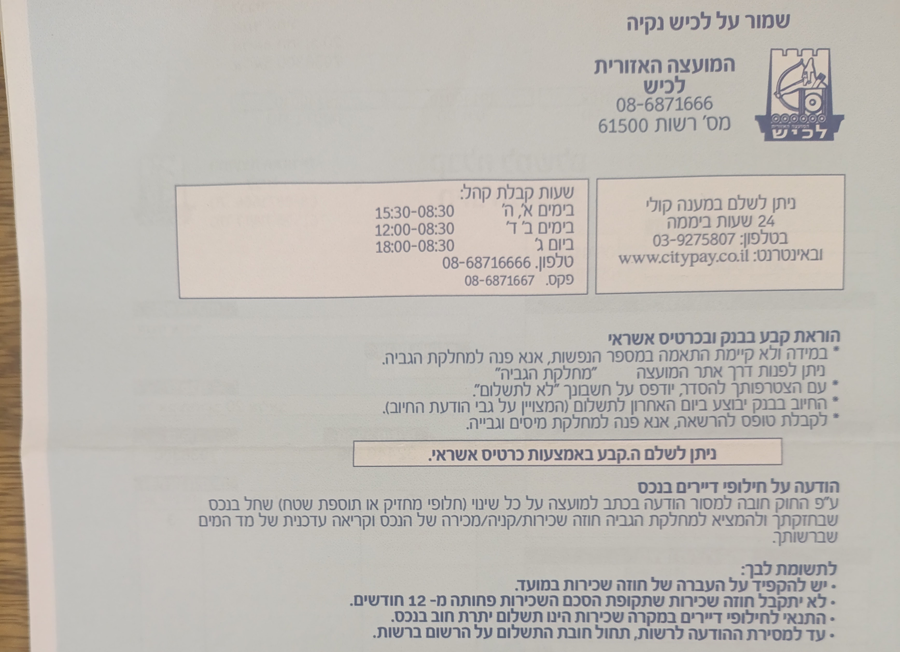

In [3]:
page_img = Image.open(SCAN_PATH).convert("RGB")
print("scan resolution:", page_img.size)

# show a downsized preview
preview = page_img.copy()
preview.thumbnail((900, 1200))
preview

## 2 — Image preprocessing

A scanner gives you a near-perfect page. A phone camera does not. Before
OCR we always:

- **Grayscale** the image — colour rarely helps an OCR engine and often
  confuses one (the red ink on this page is a great example).
- **Contrast-boost** — most phone scans are slightly washed out.
- **Light denoise** — JPEG compression and paper texture add high-frequency
  noise that hurts character segmentation.

Production pipelines also **deskew** (rotate to make text-lines horizontal)
and **dewarp** (correct page curl). We skip those here because the tilt on
this scan is small enough that the OCR engines can handle it directly; in
a real pipeline you would use `opencv` for both.

preprocessed size: (1600, 1159)


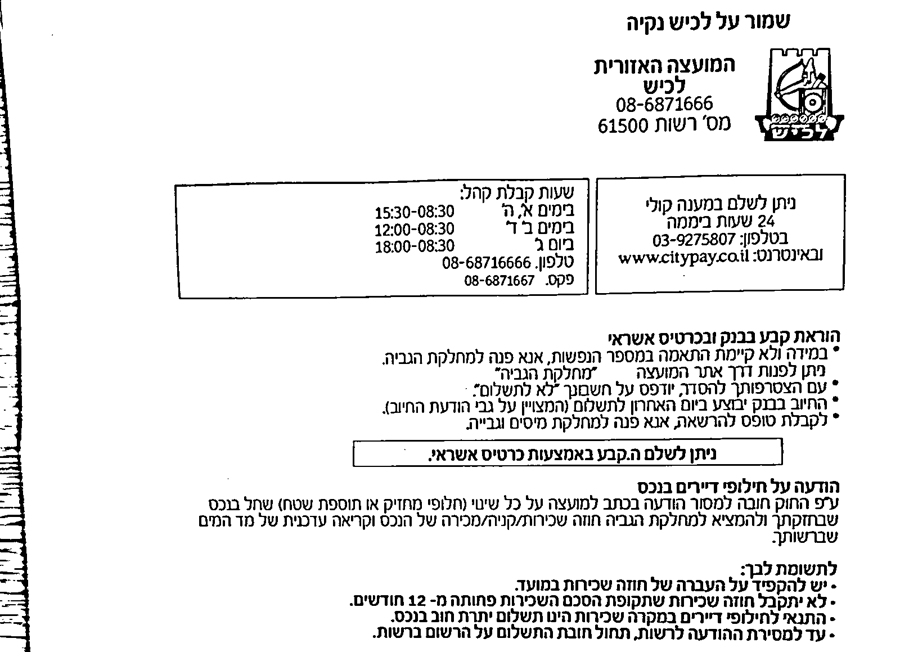

In [4]:
from PIL import ImageOps, ImageFilter, ImageEnhance

MAX_DIM = 1600  # cap longest side — OCR engines don't need 12-megapixel input

def adaptive_threshold(img: Image.Image, block_size: int = 35, c: int = 11) -> Image.Image:
    """Binarize a page while adapting to local shadows and uneven lighting."""
    import cv2

    gray = np.array(ImageOps.grayscale(img))
    if block_size % 2 == 0:
        block_size += 1
    block_size = max(3, block_size)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, c,
    )
    return Image.fromarray(binary)

def preprocess(img: Image.Image, apply_threshold: bool = True) -> Image.Image:
    # Downscale huge phone scans to a sane working size
    if max(img.size) > MAX_DIM:
        ratio = MAX_DIM / max(img.size)
        new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
        img = img.resize(new_size, Image.LANCZOS)
    gray = ImageOps.grayscale(img)
    sharp = gray.filter(ImageFilter.MedianFilter(size=3))      # light denoise
    bright = ImageEnhance.Contrast(sharp).enhance(1.4)         # boost contrast
    if apply_threshold:
        bright = adaptive_threshold(bright)
    return bright.convert("RGB")

prep_img = preprocess(page_img)
prep_img.save(ARTIFACTS / "preprocessed.png")
print("preprocessed size:", prep_img.size)

preview = prep_img.copy()
preview.thumbnail((900, 1200))
preview


## 3 — Try the wrong OCR engine first

Let's deliberately use the wrong tool. **EasyOCR** is great for Latin scripts
but ships **no Hebrew model**. We point it at the preprocessed page and watch
what comes out.

The same outcome would hold for any other Latin-only OCR (DocTR's English
model, vanilla Tesseract without `heb` data). The lesson — **pick your OCR
engine based on the script, not on convenience** — is the same.

In [34]:
import easyocr

reader_en = easyocr.Reader(['en'], gpu=False, verbose=False)
ocr_en    = reader_en.readtext(np.array(prep_img))

print(f"EasyOCR (en-only) detected {len(ocr_en)} text regions. First 15:")
for bbox, text, conf in ocr_en[:15]:
    print(f"  conf={conf:.2f}   {text!r}")

# Pure-Latin tokens (mostly the embedded numbers/dates) come out reasonable;
# the Hebrew body is hallucinated as random Latin characters.

EasyOCR (en-only) detected 41 text regions. First 15:
  conf=0.06   "7'1) U'3h JV Jinu"
  conf=0.07   ")'TITRi 2xvinn"
  conf=0.38   'uib'
  conf=0.85   '08-6871666'
  conf=0.18   "61500 niu7 'On)"
  conf=0.26   'Jnp nbp nivu'
  conf=0.10   "'JIp nwvnj dJut 0')"
  conf=0.78   '15.30-08330'
  conf=0.07   "7,0'nn"
  conf=0.50   '12.00-0830'
  conf=0.13   "J 0'm"
  conf=0.18   'ann  nIVu 24'
  conf=0.43   '18.00-0830'
  conf=0.17   '1 0i1'
  conf=0.36   '03-9275807 ;119701'


### What just happened

EasyOCR's English model can only emit characters from its training alphabet,
so when it encounters Hebrew glyphs it produces **plausible-looking Latin
gibberish**. Confidence scores are low for those regions, but not zero — and
that's the trap. If you only logged the text and not the confidence, this
output would silently poison your retrieval index.

For a real Hebrew pipeline you would install one of:

```bash
# option A — Tesseract with the Hebrew traineddata
sudo apt install tesseract-ocr tesseract-ocr-heb
pip install pytesseract

# option B — PaddleOCR with the multilingual model
pip install paddleocr
```
or
```bash
conda install -c conda-forge tesseract pytesseract
```

Neither is available in this env. So we take a third option: **use a
multimodal LLM as the OCR engine**.

In [23]:
%conda install -c conda-forge tesseract pytesseract

Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/amir/miniconda3/envs/llm

  added / updated specs:
    - pytesseract
    - tesseract


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    giflib-5.2.2               |       hd590300_0          75 KB  conda-forge
    icu-78.3                   |       h33c6efd_0        12.1 MB  conda-forge
    lcms2-2.19.1               |       h0c24ade_0         245 KB  conda-forge
    leptonica-1.87.0           |       h12c84f9_1         2.5 MB  conda-forge
    lerc-4.1.0                 | 

In [35]:
import pytesseract
img = prep_img if 'prep_img' in globals() else Image.open(SCAN_PATH).convert('RGB')
try:
    text_tess = pytesseract.image_to_string(img, lang='heb')
except Exception:
    text_tess = pytesseract.image_to_string(img)
text_tess = text_tess.strip()
if text_tess:
    (ARTIFACTS / 'ocr_tesseract_heb.txt').write_text(text_tess, encoding='utf-8')
    print('[Tesseract output saved to]', ARTIFACTS / 'ocr_tesseract_heb.txt')
    print(text_tess[:600])
else:
    print('[Tesseract produced no text]')


[Tesseract output saved to] artifacts_m13/ocr_tesseract_heb.txt
שמור על לכיש נקיה

המועצה האזורית

כיש
0-66"
מס' רשות 61500

שעות קבלת קהל:

בימים א, ה' 10
בימים בד 10
ביום ב 0

ניתן לשלם במענה קולי
4 שעות ביממה
בטלפון: 03-9275807
ובאינטרנט: |ו.0סקגק וסאי

טלפון. 08-68716666
פקס. 08-6871667

הוראת קרע בבנק ובכרטיס אשראי

במידה ולא קיימת התאמה במספר הנפשות, אנא פנה למחלקת הגביה.
ניתן לפנות זדך אתר המועצה "מחלקת הגביה"
* עם הצטרפותך להסדר, יודפס על חשבונך "לא לתשלום" :

החיוב בבנק יבוצע ביום האחרון לתשלום (המצויין על גבי הודעת החיוב).
* לקבלת טופס להרשאה, אנא פנה למחלקת מיסים וגבייה.

ניתן לשלם ה.קבע באמצעות כרטיס אשראי. '

הודעה על חילופי דיירים בנכס

ע"פ ה


In [5]:
from dotenv import load_dotenv
load_dotenv("/home/amir/.env")  # Load environment variables from .env file if present


True

In [9]:
OCR_PROMPT = (
    "Transcribe every line of text in this scanned Hebrew document. "
    "Keep the original line order, top to bottom. Use logical (Unicode) "
    "order for Hebrew — do NOT mirror or reverse the letters. Keep numbers "
    "and dates left-to-right exactly as they appear. Preserve the table "
    "structure by using one line per row, with cells separated by ' | '. "
    "Return ONLY the transcribed text, no commentary."
)

In [17]:
# using OpenAI's OCR endpoint, which is based on a fine-tuned Donut-like model.
# If OPENAI_API_KEY is set this will call the vision/responses API and save the transcribed text;
# otherwise it will print a message and leave the notebook unchanged.
# openai models - gpt-4o-mini, gpt-4.1, gpt-5.4-mini, gpt-5.5

from openai import OpenAI

# ensure a local base64 helper exists (some cells may define it later)
if '_b64_jpeg' not in globals():
    def _b64_jpeg(path: Path) -> str:
        return base64.standard_b64encode(path.read_bytes()).decode()

client = OpenAI()
# img_b64 = _b64_jpeg(SCAN_PATH)
img_b64 = _b64_jpeg(ARTIFACTS / "preprocessed.png")
# Send image as a data-URI under 'image_url' (Responses API expects a URL/data-URI)
data_uri = f"data:image/jpeg;base64,{img_b64}"
resp = client.responses.create(
    model="gpt-5.5",  # accepts image input
    input=[{
        "role": "user",
        "content": [
            {"type": "input_image", "image_url": data_uri},
            {"type": "input_text", "text": OCR_PROMPT},
        ],
    }],
    reasoning={"effort": "none"},
    max_output_tokens=2000,
)

# Prefer the simple output_text if present
ocr_text = getattr(resp, 'output_text', None) or None
if not ocr_text:
    parts = []
    for out in getattr(resp, 'output', []) or []:
        if isinstance(out, dict):
            for c in out.get('content', []) or []:
                if isinstance(c, dict) and c.get('type') in ('output_text', 'text') and c.get('text'):
                    parts.append(c.get('text'))
    ocr_text = '\n'.join(parts).strip() if parts else None
if ocr_text:
    (ARTIFACTS / 'ocr_openai.txt').write_text(ocr_text, encoding='utf-8')
    print('[OpenAI OCR saved to]', ARTIFACTS / 'ocr_openai.txt')
    print(ocr_text)
else:
    print('[OpenAI returned no text]')


[OpenAI OCR saved to] artifacts_m13/ocr_openai.txt
שמור על לכיש נקיה
המועצה האזורית
לכיש
08-6871666
מס' רשות 61500

ניתן לשלם במענה קולי
24 שעות ביממה
בטלפון: 03-9275807
ובאינטרנט: www.citypay.co.il

שעות קבלת קהל:
ביום א' ה' | 15:30-08:30
ביום ב' ד' | 12:00-08:30
ביום ג' | 18:00-08:30
טלפון. | 08-6871666
פקס. | 08-6871667

הוראת קבע בבנק ובכרטיס אשראי
• במידה ולא קיימת התאמה במספרי הנפשות, אנא פנה למחלקת הגביה.
ניתן לפנות דרך אתר המועצה.
• עם הצטרפותך להסדר יודפס על החשבון "לא לתשלום".
• החיוב בבנק יבוצע ביום האחרון לתשלום (המצויין על גבי הודעת החיוב).
לקבלת טופס להרשאה, אנא פנה למחלקת מיסים וגבייה.
ניתן לשלם הקבע באמצעות כרטיס אשראי.

הודעה על חילופי דיירים בנכס
עפ"י החוק חובה למסור הודעה בכתב למועצה על כל שינוי וחילופי מחזיק (או תוספת שטח) של הנכס
שבחזקתך ולהמציא למחלקת הגביה חוזה שכירות/מכירה של הנכס וקריאה עדכנית של מד המים
שברשותך.

לתשומת לב:
• יש להקפיד על העברה של חוזה שכירות במועד.
• לא יתקבל חוזה שכירות שתקופת הסכם השכירות פחותה מ- 12 חודשים.
• התנאי לחילופי דיירים במקרה שכי

In [15]:
resp

Response(id='resp_080edfbe5caaaf9c006a148aa963fc8195ad8e8d436777a2d0', created_at=1779731113.0, error=None, incomplete_details=IncompleteDetails(reason='max_output_tokens'), instructions=None, metadata={}, model='gpt-5.5-2026-04-23', object='response', output=[ResponseReasoningItem(id='rs_080edfbe5caaaf9c006a148aab9398819596998eb05c4f63a2', summary=[], type='reasoning', content=None, encrypted_content=None, status=None)], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=0.98, background=False, completed_at=None, conversation=None, max_output_tokens=2000, max_tool_calls=None, previous_response_id=None, prompt=None, prompt_cache_key=None, prompt_cache_retention='24h', reasoning=Reasoning(effort='medium', generate_summary=None, summary=None, context='current_turn'), safety_identifier=None, service_tier='default', status='incomplete', text=ResponseTextConfig(format=ResponseFormatText(type='text'), verbosity='medium'), top_logprobs=0, truncation='disabled', usa

## 4 — Use Claude multimodal as the OCR engine

Modern multimodal LLMs are *very* good Hebrew OCR engines. The trade-off is
familiar: API cost and latency in exchange for skipping the whole
install-and-tune cycle for a per-language OCR model.

The cell below:

- If `ANTHROPIC_API_KEY` is set → asks **`claude-sonnet-4-6`** to transcribe
  the preprocessed page into clean Hebrew, preserving line breaks and the
  table structure.
- Otherwise → loads a pre-transcribed copy of the document so the rest of the
  notebook still runs offline.

The output of either path is the **same string** — that's the point. The
retrieval pipeline downstream doesn't care which OCR engine produced it.

In [ ]:

def _b64_jpeg(path: Path) -> str:
    return base64.standard_b64encode(path.read_bytes()).decode()

def claude_ocr(img_path: Path) -> str | None:
    if not os.environ.get("ANTHROPIC_API_KEY"):
        return None
    try:
        import anthropic
        client = anthropic.Anthropic()
        msg = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2000,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image",
                     "source": {"type": "base64",
                                "media_type": "image/jpeg",
                                "data": _b64_jpeg(img_path)}},
                    {"type": "text", "text": OCR_PROMPT},
                ],
            }],
        )
        return msg.content[0].text
    except Exception as e:
        print(f"[Claude call failed: {type(e).__name__}: {e}]\n[falling back to pre-transcribed text]")
        return None


ocr_text = claude_ocr(SCAN_PATH)
if ocr_text is None:
    print("[using pre-transcribed fallback]\n")
    ocr_text = PRE_TRANSCRIBED
else:
    print("[Claude multimodal transcribed the page]\n")

# Cache to disk so the rest of the notebook is deterministic across reruns
(ARTIFACTS / "ocr_text.txt").write_text(ocr_text, encoding="utf-8")
print(ocr_text[:600], "…")

[Claude multimodal transcribed the page]

שמור על לכיש נקיה

המועצה האזורית
לכיש
08-6871666
מס' רשות 61500

שעות קבלת קהל: | ניתן לשלם במענה קולי
בימים א', ה' 08:30-15:30 | 24 שעות ביממה
בימים ב'-ד' 08:30-12:00 | בטלפון: 03-9275807
ביום ג' 08:30-18:00 | ובאינטרנט: www.citypay.co.il
טלפון. 08-68716666 |
פקס. 08-6871667 |

הוראת קבע בבנק ובכרטיס אשראי
* במידה ולא קיימת התאמה במספר הנפשות, אנא פנה למחלקת הגבייה.
ניתן לפנות דרך אתר המועצה "מחלקת הגבייה"
* עם הצטרפותך להסדר, יודפס על חשבונך "לא לתשלום".
* החיוב בבנק יבוצע ביום האחרון לתשלום (המצוין על גבי הודעת החיוב).
* לקבלת טופס להרשאה, אנא פנה למחלקת מיסים וגבייה.

ניתן לשלם ה.קבע באמצ …


## 5 — Normalize the OCR text

Even with Claude as the OCR engine, three normalization steps are still
worth running before we touch any embeddings:

- **Unicode NFC** — collapse equivalent letter forms (final-letter variants,
  decomposed niqqud) so search matches regardless of how the same character
  was encoded.
- **Whitespace cleanup** — collapse repeated spaces and stripped trailing
  whitespace.
- **Visual→logical reversal of Hebrew runs** — Claude already returns logical
  order, but the helper below is what you'd reach for if a Hebrew OCR engine
  (Tesseract, PaddleOCR, EasyOCR) returned visual-order strings. We keep it
  in the notebook because you *will* hit this with a non-VLM engine.

In [42]:
HEB_RE = re.compile(r"[\u0590-\u05FF]")

def is_hebrew(s: str) -> bool:
    return bool(HEB_RE.search(s))

def visual_to_logical_hebrew(visual: str) -> str:
    '''Inverse of BiDi for OCR engines that emit visual-order Hebrew.

    Claude returns logical order already, so this is a no-op on its output.
    With Tesseract / PaddleOCR you would set ``apply=True`` and feed every
    Hebrew line through it before indexing.
    '''
    if not is_hebrew(visual):
        return visual
    tokens = re.findall(r"[\u0590-\u05FF]+|[^\u0590-\u05FF]+", visual)
    return "".join(t[::-1] if HEB_RE.search(t) else t for t in tokens)

def normalize_line(line: str, apply_bidi_inverse: bool = False) -> str:
    line = unicodedata.normalize("NFC", line)
    line = re.sub(r"[ \t]+", " ", line).strip()
    if apply_bidi_inverse:
        line = visual_to_logical_hebrew(line)
    return line

# Claude's transcription is already in logical order, so apply_bidi_inverse=False.
normalized_lines = [normalize_line(ln) for ln in ocr_text.splitlines()]
normalized_lines = [ln for ln in normalized_lines if ln]

print(f"normalized lines: {len(normalized_lines)}")
for ln in normalized_lines[:10]:
    print(" ", ln)

normalized lines: 6
  שמור על נכש נקה | המועצה האזורית | לינש | 08-6871666 | מס' רשות 61500
  שעות קבלת קהל: | בימים א', ג' | 15:30-08:30 | בימים ב' | 12:00-08:30 | 18:00-08:30 | | טלפון: 08-6871666 | פקס: 08-6871667
  כיתוב בנוסף | ניתן לשלם באמצעות כרטיס אשראי. | יש להגיע איתך את המסמך הנדרש, או פנה טלפן למשרד החינוך. | ניתנת בנוסף גם ההנחות על פי סעיף 'חוק חינוך חינם'.
  לשירותך בלב: | יש להגיש את הבקשה למשרד החינוך עד 12 חודשים. | זאת ניתן להגיש אם יש לך שיבוץ קיים בגן. | אפשר תשלום על פי הרישום הקודם.
  הודעה על התשלומים: | מצטערת ההודעה שעל כל שיטה | גילוי מחודש או הוספת שיטה שתלך בכניס | האתר שלך שתתמוך | במזומן או בכרטיס אשראי.
  ניתן לשלם המועצה בכרטיס אשראי. |


### What the BiDi inverse actually does

To make this concrete, we apply `visual_to_logical_hebrew` to a deliberately
visual-order Hebrew sample — the kind of string Tesseract would have produced
if it had read this page. The numbers stay LTR; only the Hebrew runs flip.

In [43]:
# A single Hebrew word with a date next to it.
# Visual order (what a non-BiDi-aware OCR would emit), logical order shown for comparison.
visual_sample = "10/02/26 ןושאר םוי"        # "first day 10/02/26" in visual order
expected_log  = "10/02/26 ראשון יום"        # individual Hebrew runs flipped

fixed = " ".join(visual_to_logical_hebrew(tok) for tok in visual_sample.split())

print("raw (visual order):  ", visual_sample)
print("after BiDi inverse:  ", fixed)
print("expected logical:    ", expected_log)

raw (visual order):   10/02/26 ןושאר םוי
after BiDi inverse:   10/02/26 ראשון יום
expected logical:     10/02/26 ראשון יום


### Final clean text

We concatenate the normalized lines back into a single page string. This
is what we'll chunk and index.

In [44]:
clean_text = "\n".join(normalized_lines)
print(clean_text)

שמור על נכש נקה | המועצה האזורית | לינש | 08-6871666 | מס' רשות 61500
שעות קבלת קהל: | בימים א', ג' | 15:30-08:30 | בימים ב' | 12:00-08:30 | 18:00-08:30 | | טלפון: 08-6871666 | פקס: 08-6871667
כיתוב בנוסף | ניתן לשלם באמצעות כרטיס אשראי. | יש להגיע איתך את המסמך הנדרש, או פנה טלפן למשרד החינוך. | ניתנת בנוסף גם ההנחות על פי סעיף 'חוק חינוך חינם'.
לשירותך בלב: | יש להגיש את הבקשה למשרד החינוך עד 12 חודשים. | זאת ניתן להגיש אם יש לך שיבוץ קיים בגן. | אפשר תשלום על פי הרישום הקודם.
הודעה על התשלומים: | מצטערת ההודעה שעל כל שיטה | גילוי מחודש או הוספת שיטה שתלך בכניס | האתר שלך שתתמוך | במזומן או בכרטיס אשראי.
ניתן לשלם המועצה בכרטיס אשראי. |


## 6 — Chunk and embed with a multilingual model

We deliberately chose a **multilingual** sentence-transformer
(`paraphrase-multilingual-MiniLM-L12-v2`) so that an English query can retrieve
a Hebrew chunk and vice-versa. This is one of the smallest practical
multilingual embedders — fine for a demo, you would swap to `bge-m3` or
`multilingual-e5-large` in production.

In [9]:
from sentence_transformers import SentenceTransformer

# split the normalized page into paragraph-ish chunks
def chunk_page(text: str, target_chars: int = 220):
    parts = re.split(r"\n+", text)
    chunks, buf = [], ""
    for p in parts:
        if len(buf) + len(p) + 1 > target_chars and buf:
            chunks.append(buf.strip()); buf = p
        else:
            buf = (buf + "\n" + p).strip() if buf else p
    if buf: chunks.append(buf.strip())
    return [c for c in chunks if c]

chunks = chunk_page(clean_text)
for i, c in enumerate(chunks):
    print(f"--- chunk {i} ---\n{c}\n")

--- chunk 0 ---
לכבוד
אגוזי אמיר
אליאב החרב 20
אליאב 7938300
קבלה למשלם
חשבון שנתי של מיסים לשנת 2026
החיוב עשוי להשתנות במהלך השנה בהתאם לחקיקה.
המועצה האזורית לכיש
טל. 08-6871666
מס' רשות 61500
מספר המשלם: 32440109

--- chunk 1 ---
פרטי המשלם: אגוזי אמיר אליאב החרב 20 אליאב 7938300
* בעל הוראת קבע: שים לב שהסכום אשר יוכה מחשבונך בבנק מקודד מחשבונך השנתי.
תקופת מיסים: 01-12/26
פרטי הנכס: אליאב 140
אזור: 36

--- chunk 2 ---
* על כל שינוי ברכוש או החלפת דירה, יש להודיע מיד למחלקת הגבייה.
טבלת חיובים:
הסכום | סוג חיוב | תאור השירות | סימול | תאור הפעולה | סוג נכס | תאור נכס | גודל

--- chunk 3 ---
7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת ביוב | 165.00
-146.30 | | | | הנחת תשלום מראש | | |
-1,194.40 | | | | ישולם בהוראת קבע באשראי | | |
הסכום לתשלום: 5,972.10 שקל חדש
לתשלום עד: 10/02/26

--- chunk 4 ---
מספר מסלקה: 195432522
הנחה בשיעור 4% מהחיוב השנתי למשלם עד 29.2.2026.
בתנאי שישלם את כל יתרת החוב עד 31.12.2026.



In [10]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb   = model.encode(chunks, normalize_embeddings=True)
print("embeddings shape:", emb.shape)

embeddings shape: (5, 384)


## 7 — Tiny retrieval index

We skip FAISS for this demo — with a handful of chunks, a `numpy` dot product
is the most readable implementation. The retrieval logic is the same; FAISS
becomes worth its weight only at thousands of vectors.

In [11]:
def retrieve(query: str, k: int = 2):
    q = model.encode([query], normalize_embeddings=True)[0]
    sims = emb @ q
    top  = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i]), chunks[i]) for i in top]

queries = [
    "מה הסכום הסופי לתשלום?",
    "עד מתי צריך לשלם את החשבון?",
    "מה מספר המשלם ומה כתובת הנכס?",
    "What discount is offered for early payment?",
]

for q in queries:
    print(f"\nQ: {q}")
    for idx, score, text in retrieve(q):
        snippet = text.replace("\n", " ")[:80]
        print(f"  [{idx}] {score:.3f}   {snippet}…")


Q: מה הסכום הסופי לתשלום?
  [3] 0.649   7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת ביוב | 165.0…
  [4] 0.592   מספר מסלקה: 195432522 הנחה בשיעור 4% מהחיוב השנתי למשלם עד 29.2.2026. בתנאי שישל…

Q: עד מתי צריך לשלם את החשבון?
  [4] 0.536   מספר מסלקה: 195432522 הנחה בשיעור 4% מהחיוב השנתי למשלם עד 29.2.2026. בתנאי שישל…
  [0] 0.487   לכבוד אגוזי אמיר אליאב החרב 20 אליאב 7938300 קבלה למשלם חשבון שנתי של מיסים לשנת…

Q: מה מספר המשלם ומה כתובת הנכס?
  [1] 0.540   פרטי המשלם: אגוזי אמיר אליאב החרב 20 אליאב 7938300 * בעל הוראת קבע: שים לב שהסכו…
  [3] 0.508   7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת ביוב | 165.0…

Q: What discount is offered for early payment?
  [3] 0.459   7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת ביוב | 165.0…
  [4] 0.431   מספר מסלקה: 195432522 הנחה בשיעור 4% מהחיוב השנתי למשלם עד 29.2.2026. בתנאי שישל…


## 8 — Generate an answer

Two paths, picked at runtime:

- If `ANTHROPIC_API_KEY` is set, we send the retrieved chunks to
  **`claude-sonnet-4-6`** and get a real grounded answer.
- Otherwise we fall back to a tiny extractive heuristic so the notebook still
  runs offline.

Either way, the **retrieval step is identical** — that's the point of
keeping the LLM at the end of the pipeline rather than tangled into it.

In [12]:
SYSTEM = (
    "You are an assistant that answers questions about a scanned Israeli "
    "annual property-tax bill (Arnona). Use ONLY the provided context. "
    "If the answer is not in the context, say so. Answer in the language of the question."
)

def answer_with_claude(query: str, ctx_chunks: list[str]) -> str | None:
    if not os.environ.get("ANTHROPIC_API_KEY"):
        return None
    try:
        import anthropic
        client = anthropic.Anthropic()
        ctx = "\n\n---\n\n".join(ctx_chunks)
        msg = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=400,
            system=SYSTEM,
            messages=[{"role": "user",
                       "content": f"Context:\n{ctx}\n\nQuestion: {query}"}],
        )
        return msg.content[0].text
    except Exception as e:
        print(f"  [Claude call failed: {type(e).__name__}; using fallback]")
        return None

def answer_fallback(query: str, ctx_chunks: list[str]) -> str:
    '''Deterministic extractive baseline — no LLM.'''
    return ctx_chunks[0] if ctx_chunks else "(no context)"

def answer(query: str, k: int = 2) -> str:
    hits = retrieve(query, k=k)
    ctx  = [t for _, _, t in hits]
    out  = answer_with_claude(query, ctx)
    if out is None:
        out = "[fallback, no API key]\n" + answer_fallback(query, ctx)
    return out

for q in queries[:2]:
    print("Q:", q)
    print("A:", answer(q))
    print("---")

Q: מה הסכום הסופי לתשלום?


  [Claude call failed: BadRequestError; using fallback]
A: [fallback, no API key]
7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת ביוב | 165.00
-146.30 | | | | הנחת תשלום מראש | | |
-1,194.40 | | | | ישולם בהוראת קבע באשראי | | |
הסכום לתשלום: 5,972.10 שקל חדש
לתשלום עד: 10/02/26
---
Q: עד מתי צריך לשלם את החשבון?


  [Claude call failed: BadRequestError; using fallback]
A: [fallback, no API key]
מספר מסלקה: 195432522
הנחה בשיעור 4% מהחיוב השנתי למשלם עד 29.2.2026.
בתנאי שישלם את כל יתרת החוב עד 31.12.2026.
---


## 9 — Where OCR-first RAG fails

Now try these queries against the same text-only index:

- *"What does the council logo look like, and what colour is it?"*
- *"Show me the row of the table that contains a negative number."*
- *"Which field on the form is printed inside a red box?"*
- *"Is the document signed or stamped at the bottom?"*

All four need information **the OCR step threw away** — colour, layout,
typography, marks. The retrieved chunks here will be lexically *plausible*
but semantically irrelevant.

This is the bridge to Meeting 14:

- **CLIP / SigLIP**-style models can embed the *page image* into the same
  vector space as text queries.
- **Multimodal LLMs** (Claude, GPT-4o, LLaVA) can read the page directly
  and answer questions that have no text-only answer.
- A **hybrid** index — text chunks + page-image embeddings — covers both
  worlds, and is what we'll build next week.

> The failures below are not bugs in this notebook. They are the *point* of
> this notebook: exactly the gap that VLMs were invented to close.

In [13]:
visual_qs = [
    "Which row of the table contains a negative number?",
    "Which field on the form is printed inside a red box?",
    "Is there a council logo on the page, and what colour is it?",
]
for q in visual_qs:
    print("Q:", q)
    for idx, score, text in retrieve(q, k=1):
        print(f"  top-1 score={score:.3f}  → {text[:70]}…")
    print("(OCR-first index has no way to answer this — see M14.)\n")

Q: Which row of the table contains a negative number?
  top-1 score=0.265  → 7,312.80 | 5 | ארנונה 2026 | 20 | חיוב שנתי | 102 | מ.מגורים + אגרת בי…
(OCR-first index has no way to answer this — see M14.)

Q: Which field on the form is printed inside a red box?
  top-1 score=0.185  → לכבוד
אגוזי אמיר
אליאב החרב 20
אליאב 7938300
קבלה למשלם
חשבון שנתי של …
(OCR-first index has no way to answer this — see M14.)

Q: Is there a council logo on the page, and what colour is it?
  top-1 score=0.265  → * על כל שינוי ברכוש או החלפת דירה, יש להודיע מיד למחלקת הגבייה.
טבלת ח…
(OCR-first index has no way to answer this — see M14.)



## Takeaways

- A real phone-camera scan needs **image preprocessing** before any OCR — at
  minimum grayscale + contrast. Deskew and dewarp matter for more tilted shots.
- **Picking the OCR engine matters more than the rest of the pipeline put together.**
  EasyOCR has no Hebrew model, so we used Claude multimodal as a one-shot OCR.
  Tesseract `+heb` or PaddleOCR would be the open-source equivalents.
- **Normalization** (Unicode NFC + whitespace + BiDi-inverse when needed) is
  cheap insurance against silent retrieval failures.
- A multilingual sentence-transformer makes **cross-language retrieval** free:
  English queries match Hebrew chunks, Hebrew queries match English chunks.
- The Claude generation step is interchangeable with a deterministic fallback
  because the retriever is doing the real work.

Next week we **keep this exact retrieval index** — and add a second one over
*page images*. That's multimodal RAG.

## 2.5 — Structure-first OCR: detect regions, then OCR crops

For forms and tables, page-level OCR is often the wrong unit of work. A stronger pipeline is:

1. Detect the page layout.
2. Detect text regions or table cells as bounding boxes.
3. OCR each crop separately.
4. Store `{bbox, text, confidence, region_type}` so retrieval can preserve document structure.

The cell below uses OpenCV morphology to find likely text blocks and ruled table cells. It is heuristic, but it is a good baseline before moving to a dedicated layout model such as LayoutParser / Detectron2, PaddleOCR's layout pipeline, or a document AI service.


text regions detected: 8
ruled table cell candidates detected: 4


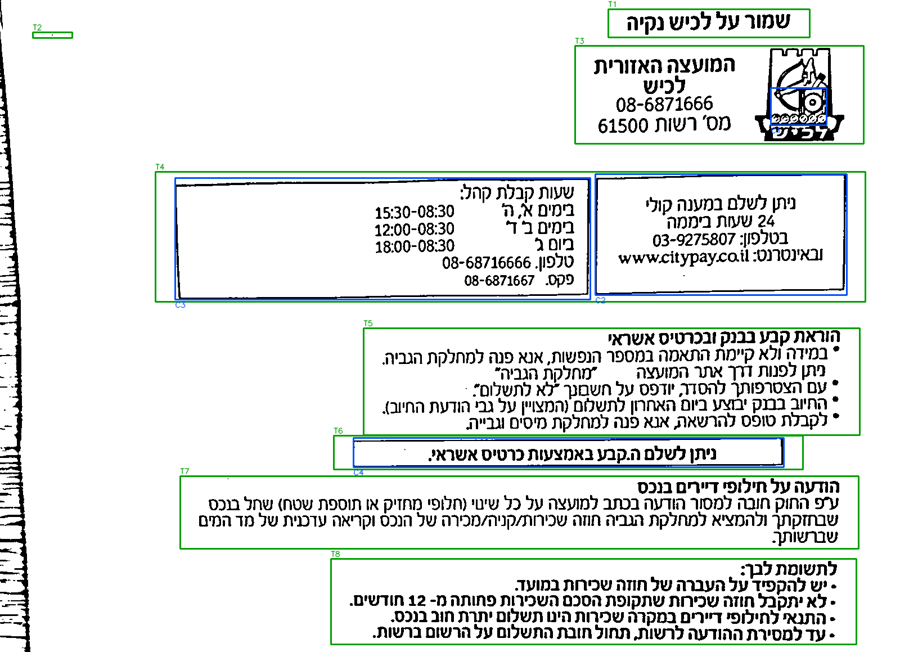

In [ ]:
import cv2
from IPython.display import display


def _contour_boxes(mask, *, min_area=250, max_area_ratio=0.8):
    h, w = mask.shape[:2]
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh
        if area < min_area or area > max_area_ratio * w * h:
            continue
        if bw < 8 or bh < 8:
            continue
        # Drop page-edge artifacts: very tall, narrow strips are usually borders/shadows.
        if bh > 0.75 * h and bw < 0.12 * w:
            continue
        boxes.append((x, y, bw, bh))
    return sorted(boxes, key=lambda b: (b[1], b[0]))


def detect_text_regions(img: Image.Image):
    gray = cv2.cvtColor(np.array(img.convert("RGB")), cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

    h, w = binary.shape[:2]
    # Join nearby letters into word/line blocks without merging the whole page.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(18, w // 45), max(4, h // 220)))
    joined = cv2.dilate(binary, kernel, iterations=2)
    boxes = _contour_boxes(joined, min_area=max(180, (w * h) // 8000))
    return boxes, binary


def detect_ruled_table_cells(binary):
    h, w = binary.shape[:2]
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(30, w // 22), 1))
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(25, h // 28)))
    horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
    vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel, iterations=1)
    grid = cv2.add(horizontal, vertical)

    contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    cells = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh
        if area < 400 or bw < 18 or bh < 12:
            continue
        if bw > 0.95 * w or bh > 0.60 * h:
            continue
        cells.append((x, y, bw, bh))

    # Remove near-duplicates caused by inner and outer borders.
    deduped = []
    for box in sorted(cells, key=lambda b: (b[1], b[0], b[2] * b[3])):
        x, y, bw, bh = box
        if not any(abs(x-x2) < 4 and abs(y-y2) < 4 and abs(bw-bw2) < 8 and abs(bh-bh2) < 8
                   for x2, y2, bw2, bh2 in deduped):
            deduped.append(box)
    return deduped


def draw_boxes(img: Image.Image, boxes, color, label_prefix=None):
    canvas = np.array(img.convert("RGB")).copy()
    for i, (x, y, w, h) in enumerate(boxes, start=1):
        cv2.rectangle(canvas, (x, y), (x+w, y+h), color, 2)
        if label_prefix:
            cv2.putText(canvas, f"{label_prefix}{i}", (x, max(12, y-4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return Image.fromarray(canvas)


text_boxes, binary = detect_text_regions(prep_img)
cell_boxes = detect_ruled_table_cells(binary)

print(f"text regions detected: {len(text_boxes)}")
print(f"ruled table cell candidates detected: {len(cell_boxes)}")

annotated = np.array(prep_img.convert("RGB")).copy()
for i, (x, y, w, h) in enumerate(text_boxes, start=1):
    cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 160, 0), 2)
    cv2.putText(annotated, f"T{i}", (x, max(12, y-4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 160, 0), 1, cv2.LINE_AA)
for i, (x, y, w, h) in enumerate(cell_boxes, start=1):
    cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 80, 255), 2)
    cv2.putText(annotated, f"C{i}", (x, y+h+14), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 80, 255), 1, cv2.LINE_AA)

layout_preview = Image.fromarray(annotated)
layout_preview.save(ARTIFACTS / "layout_regions_preview.png")
layout_preview.thumbnail((900, 1200))
display(layout_preview)


### OCR each detected region

This cell keeps OCR scoped to individual boxes. With Hebrew Tesseract installed, each crop is OCR'd independently and stored with its bounding box. If Tesseract is missing, the cell still produces the crop inventory so you can inspect the segmentation step first.


In [ ]:
try:
    import pytesseract
except ImportError:
    pytesseract = None


def crop_with_padding(img: Image.Image, box, pad=6):
    x, y, w, h = box
    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(img.width, x + w + pad)
    y1 = min(img.height, y + h + pad)
    return img.crop((x0, y0, x1, y1))


def ocr_box(img: Image.Image, box, *, lang="heb+eng"):
    crop = crop_with_padding(img, box)
    if pytesseract is None:
        return ""
    config = "--psm 6"
    return pytesseract.image_to_string(crop, lang=lang, config=config).strip()


def clean_region_text(text: str) -> str:
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[ \t]+", " ", text)
    return "\n".join(line.strip() for line in text.splitlines() if line.strip())


# Text regions are the robust default for this phone scan.
# Use `cell_boxes` here only after inspecting `layout_regions_preview.png` and tuning the morphology.
ocr_boxes = text_boxes

regions = []
for idx, box in enumerate(ocr_boxes, start=1):
    text = ocr_box(prep_img, box)
    regions.append({
        "id": idx,
        "bbox_xywh": box,
        "region_type": "text_region",
        "text": clean_region_text(text) if text else "",
    })

(ARTIFACTS / "layout_regions.json").write_text(
    json.dumps(regions, ensure_ascii=False, indent=2), encoding="utf-8"
)

if pytesseract is None:
    print("pytesseract is not installed in this kernel; saved boxes only.")
print("saved:", ARTIFACTS / "layout_regions.json")
for r in regions[:12]:
    print(r)


saved: artifacts_m13/layout_regions.json
{'id': 1, 'bbox_xywh': (1081, 16, 358, 50), 'region_type': 'text_region', 'text': 'שמור על לכיש נקיה'}
{'id': 2, 'bbox_xywh': (58, 57, 70, 10), 'region_type': 'text_region', 'text': ''}
{'id': 3, 'bbox_xywh': (1022, 81, 513, 174), 'region_type': 'text_region', 'text': 'המועצה האזורית\n\u200eCbs\u200f לכיש\n9 08-6871666\n\u200evy\u200f ,\n\u200e‘OD Yaa\u200f רשות 61500'}
{'id': 4, 'bbox_xywh': (276, 305, 1262, 231), 'region_type': 'text_region', 'text': "שעות קבלת קהל:\nניתן לשלם במענה קולי בימים א, ה' 10\n24 שעות ביממה \u200eT1009\u200f 12:00-08:30\nבטלפון: 03-9275807 ביום ב 10\nובאינטרנט: \u200ewwweitypay.co.il\u200f טלפון. 08-68716666\n. פקס. 08-6871667"}
{'id': 5, 'bbox_xywh': (646, 583, 882, 190), 'region_type': 'text_region', 'text': 'הוראת קבע בבנק ובכרטיס אשראי\n* במידה ולא קיימת התאמה במספר הנפשות, אנא פנה למחלקת הגביה.\nניתן לפנות דרך אתר המועצה "מחלקת הגביה"\n\u200eoy *\u200f הצטרפותך להסדר יודפס על חשבונך "לא לתשלום" -\n\u200eana *\u2

## Optional — OCR with Docling

Docling is a document-conversion pipeline: it can run layout analysis, table detection, and OCR, then export the result as Markdown or structured JSON. This cell treats the scan as an image input and asks Docling to OCR it with Hebrew + English language hints.


In [11]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    TableStructureOptions,
    TesseractCliOcrOptions,
)
from docling.document_converter import DocumentConverter, ImageFormatOption

docling_input = SCAN_PATH
docling_input = ARTIFACTS / "preprocessed.png"

pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options = TableStructureOptions(do_cell_matching=True)
pipeline_options.ocr_options = TesseractCliOcrOptions(
    lang=["heb", "eng"],
    force_full_page_ocr=True,
)

converter = DocumentConverter(
    allowed_formats=[InputFormat.IMAGE],
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options),
    },
)

result = converter.convert(docling_input)
docling_doc = result.document
docling_md = docling_doc.export_to_markdown()
docling_json = docling_doc.export_to_dict()

(ARTIFACTS / "ocr_docling.md").write_text(docling_md, encoding="utf-8")
(ARTIFACTS / "ocr_docling.json").write_text(
    json.dumps(docling_json, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("[Docling OCR saved]")
print("Markdown:", ARTIFACTS / "ocr_docling.md")
print("JSON:", ARTIFACTS / "ocr_docling.json")
print()
print(docling_md[:1200])


[Docling OCR saved]
Markdown: artifacts_m13/ocr_docling.md
JSON: artifacts_m13/ocr_docling.json

## שמור על לכיש נקיה

המועצה האזורית כיש 08-6871666 'OD‏ רשות 61500

<!-- image -->

שעות קבלת INp‏

בימים א, ה'

10

בימים ב די

10

ניתן לשלם במענה קולי 4 שעות ביממה בטלפון: 03-9275807 wwweitypaycoail ובאינטרנט:‎

ביום ב

0

טלפון. 08-68716666

פקס. 08-6871667

## הוראת קבע בבנק ובכרטיס אשראי

- * במידה ולא קיימת התאמה במספר הנפשות, אנא mo‏ למחלקת הגביה. ניתן לפנות דרך אתר המועצה "מחלקת הגביה"

:

- * החיוב בבנק יבוצע ביום האחרון לתשלום (המצויין על גבי הודעת החיוב).
- OY *‏ הצטרפותך ATONI‏ יודפס על חשבונך "לא לתשלום"
- * לקבלת טופס להרשאה, אנא פנה למחלקת מִיסים וגבייה.

ניתן לשלם ה.קבע באמצעות כרטיס אשראי. ‏

=

## הודעה על חילופי דיירים בנכס

oY‏ החוק חובה למסור הודעה בכתב למועצה על כל שיטוי (חלופי מחזיק או תוספת (now‏ שחל בנכס שבחזקתך ולהמציא למחלקת הגביה חוזה שכירות/קניה/מכירה של הנכס וקריאה עדכנית של מד המים שברשותך

## לתשומת לבך:

- -לא יתקבל חוזה שכירות שתקופת הסכם השכירות פחותה מ1

## Visualize Docling text bounding boxes

Docling stores provenance for detected text items in `ocr_docling.json`. This cell draws those text bounding boxes back onto the original scan and labels each box with the detected text.


Docling text boxes drawn: 27
saved: artifacts_m13/docling_text_bboxes_on_original.jpg


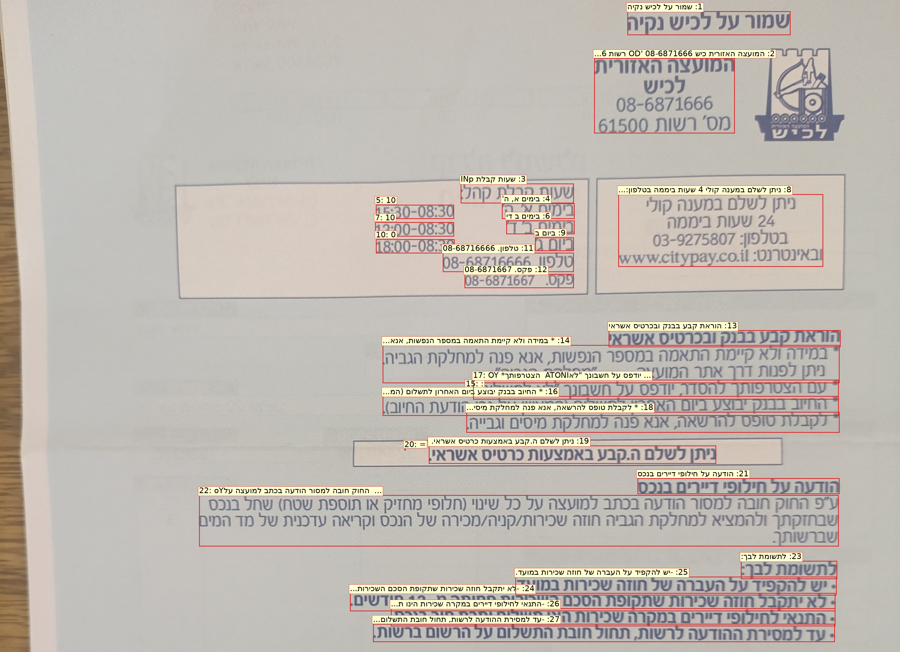

(2420, 43, 3049, 135) שמור על לכיש נקיה
(2292, 224, 2834, 514) המועצה האזורית כיש 08-6871666 'OD‏ רשות 61500
(1777, 708, 2213, 784) שעות קבלת INp‏
(1936, 784, 2216, 844) בימים א, ה'
(1450, 790, 1751, 844) 10
(1953, 851, 2216, 903) בימים ב די
(1447, 857, 1751, 912) 10
(2385, 749, 3175, 1029) ניתן לשלם במענה קולי 4 שעות ביממה בטלפון: 03-9275807 wwweitypaycoail ובאינטרנט:‎
(2064, 916, 2213, 968) ביום ב
(1450, 923, 1753, 977) 0
(1708, 975, 2213, 1049) טלפון. 08-68716666
(1792, 1057, 2213, 1111) פקס. 08-6871667
(2348, 1274, 3242, 1339) הוראת קבע בבנק ובכרטיס אשראי
(1476, 1331, 3238, 1478) * במידה ולא קיימת התאמה במספר הנפשות, אנא mo‏ למחלקת הגביה. ניתן לפנות דרך אתר המועצה "מחלקת הגביה"
(1797, 1498, 1801, 1502) :
(1476, 1528, 3235, 1604) * החיוב בבנק יבוצע ביום האחרון לתשלום (המצויין על גבי הודעת החיוב).
(1825, 1465, 3235, 1541) OY *‏ הצטרפותך ATONI‏ יודפס על חשבונך "לא לתשלום"
(1799, 1589, 3238, 1669) * לקבלת טופס להרשאה, אנא פנה למחלקת מִיסים וגבייה.
(1654, 1719, 2762, 1789) ניתן לשלם ה.ק

In [12]:
from PIL import ImageDraw, ImageFont
from IPython.display import display

DOC_JSON = ARTIFACTS / "ocr_docling.json"
assert DOC_JSON.exists(), f"Run the Docling OCR cell first; missing {DOC_JSON}"

docling_json = json.loads(DOC_JSON.read_text(encoding="utf-8"))
orig_img = Image.open(SCAN_PATH).convert("RGB")
annotated = orig_img.copy()
draw = ImageDraw.Draw(annotated)

# Docling coordinates are in the processed page coordinate system, not necessarily
# the original photo size. Convert them back to the original image dimensions.
page = docling_json["pages"]["1"]
page_w = float(page["size"]["width"])
page_h = float(page["size"]["height"])
scale_x = orig_img.width / page_w
scale_y = orig_img.height / page_h

try:
    font = ImageFont.truetype("DejaVuSans.ttf", size=max(18, orig_img.width // 115))
except OSError:
    font = ImageFont.load_default()


def docling_bbox_to_image_xyxy(bbox):
    l, t, r, b = map(float, (bbox["l"], bbox["t"], bbox["r"], bbox["b"]))
    if bbox.get("coord_origin") == "BOTTOMLEFT":
        x0 = l * scale_x
        y0 = (page_h - t) * scale_y
        x1 = r * scale_x
        y1 = (page_h - b) * scale_y
    else:
        x0 = l * scale_x
        y0 = t * scale_y
        x1 = r * scale_x
        y1 = b * scale_y
    return tuple(round(v) for v in (min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)))


def shorten_label(text, max_chars=42):
    text = " ".join(str(text).split())
    return text if len(text) <= max_chars else text[:max_chars - 1] + "..."

items = []
for item in docling_json.get("texts", []):
    text = item.get("text") or item.get("orig") or ""
    if not text.strip():
        continue
    for prov in item.get("prov", []):
        if prov.get("page_no") != 1 or "bbox" not in prov:
            continue
        items.append({
            "text": text.strip(),
            "label": item.get("label", "text"),
            "bbox": docling_bbox_to_image_xyxy(prov["bbox"]),
        })

for i, item in enumerate(items, start=1):
    x0, y0, x1, y1 = item["bbox"]
    color = (220, 40, 40)
    draw.rectangle((x0, y0, x1, y1), outline=color, width=max(3, orig_img.width // 900))

    label = f'{i}: {shorten_label(item["text"])}'
    tx, ty = x0, max(0, y0 - max(24, orig_img.height // 70))
    text_box = draw.textbbox((tx, ty), label, font=font)
    pad = 4
    draw.rectangle(
        (text_box[0] - pad, text_box[1] - pad, text_box[2] + pad, text_box[3] + pad),
        fill=(255, 255, 210),
        outline=color,
    )
    draw.text((tx, ty), label, fill=(0, 0, 0), font=font)

out_path = ARTIFACTS / "docling_text_bboxes_on_original.jpg"
annotated.save(out_path, quality=95)
print(f"Docling text boxes drawn: {len(items)}")
print("saved:", out_path)

preview = annotated.copy()
preview.thumbnail((900, 1200))
display(preview)

for item in items[:20]:
    print(item["bbox"], item["text"])
